DESCRIPTIVE STATISTICS

Item-level Statistics (first 10 items):
         Mean        SD  Min  Max
Item_1   2.76  1.393491    1    5
Item_2   3.04  1.462805    1    5
Item_3   2.96  1.413642    1    5
Item_4   3.07  1.444285    1    5
Item_5   2.99  1.424852    1    5
Item_6   3.21  1.394759    1    5
Item_7   2.90  1.500842    1    5
Item_8   2.82  1.438153    1    5
Item_9   3.09  1.422013    1    5
Item_10  2.92  1.433228    1    5

Overall Mean per Item: 2.95
Overall SD per Item: 1.43

DOMAIN STATISTICS
                Mean         SD  Mean_Item  95%_CI_Lower  95%_CI_Upper
Self_Efficacy  29.76  11.113846      2.976     27.554772     31.965228
Anxiety        28.75   9.161155      2.875     26.932228     30.567772
Engagement     29.92  10.700401      2.992     27.796808     32.043192

CRONBACH'S ALPHA
Overall Cronbach's Alpha: 0.643
Self-Efficacy Alpha: 0.926
Anxiety Alpha: 0.852
Engagement Alpha: 0.905

Alpha if Item Deleted (first 10 items):
      Item  Alpha_if_Deleted    Change
0 

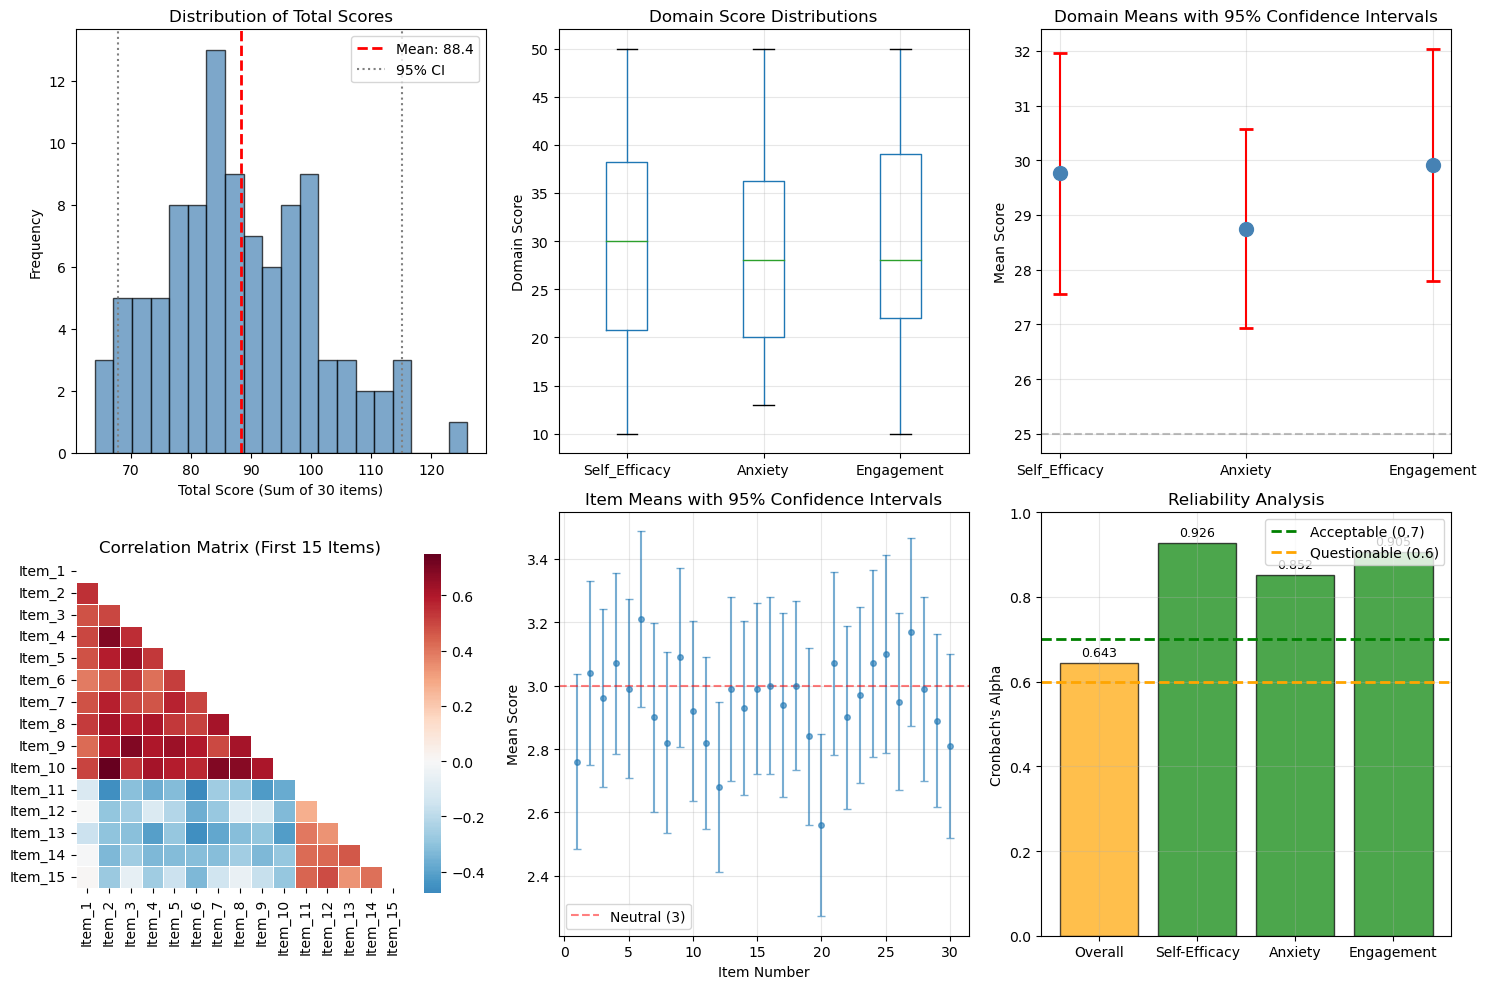


ITEM RESPONSE PATTERNS

Items with >20% floor or ceiling effects:
Item_1: 24.0% responded with minimum score (1)
Item_2: 21.0% responded with minimum score (1)
Item_2: 21.0% responded with maximum score (5)
Item_3: 21.0% responded with minimum score (1)
Item_4: 21.0% responded with minimum score (1)
Item_4: 23.0% responded with maximum score (5)
Item_5: 21.0% responded with minimum score (1)
Item_6: 22.0% responded with maximum score (5)
Item_7: 25.0% responded with minimum score (1)
Item_7: 21.0% responded with maximum score (5)
Item_8: 24.0% responded with minimum score (1)
Item_9: 23.0% responded with maximum score (5)
Item_10: 24.0% responded with minimum score (1)
Item_11: 23.0% responded with minimum score (1)
Item_12: 23.0% responded with minimum score (1)
Item_13: 24.0% responded with maximum score (5)
Item_14: 21.0% responded with minimum score (1)
Item_17: 25.0% responded with minimum score (1)
Item_19: 21.0% responded with minimum score (1)
Item_20: 32.0% responded with min

TypeError: 'bool' object is not iterable

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, t
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
n_students = 100
n_items = 30
likert_min, likert_max = 1, 5

# Simulate correlated Likert data
def generate_correlated_likert(n_students, n_items, correlation_mat):
    # Generate multivariate normal data
    mean = np.zeros(n_items)
    data = np.random.multivariate_normal(mean, correlation_mat, n_students)
    
    # Convert to uniform distribution
    data_uniform = stats.norm.cdf(data)
    
    # Convert to Likert scale (1-5)
    likert_data = np.floor(data_uniform * likert_max) + 1
    likert_data = np.clip(likert_data, likert_min, likert_max)
    
    return likert_data.astype(int)

# Create correlation structure
corr_mat = np.eye(n_items)

# Self-efficacy items (1-10): strong positive correlations
for i in range(10):
    for j in range(10):
        if i != j:
            corr_mat[i, j] = 0.6 + np.random.uniform(-0.1, 0.1)

# Anxiety items (11-20): moderate positive correlations
for i in range(10, 20):
    for j in range(10, 20):
        if i != j:
            corr_mat[i, j] = 0.4 + np.random.uniform(-0.1, 0.1)

# Engagement items (21-30): moderate positive correlations
for i in range(20, 30):
    for j in range(20, 30):
        if i != j:
            corr_mat[i, j] = 0.5 + np.random.uniform(-0.1, 0.1)

# Cross-domain correlations (weaker)
for i in range(10):
    for j in range(10, 20):
        corr_mat[i, j] = -0.3 + np.random.uniform(-0.1, 0.1)  # Negative correlation
        corr_mat[j, i] = corr_mat[i, j]
    for j in range(20, 30):
        corr_mat[i, j] = 0.2 + np.random.uniform(-0.1, 0.1)
        
for i in range(10, 20):
    for j in range(20, 30):
        corr_mat[i, j] = -0.2 + np.random.uniform(-0.1, 0.1)
        corr_mat[j, i] = corr_mat[i, j]

# Ensure positive definiteness
eigenvalues = np.linalg.eigvals(corr_mat)
if np.min(eigenvalues) < 0:
    corr_mat = corr_mat + np.eye(n_items) * (abs(np.min(eigenvalues)) + 0.01)

# Generate data
data = generate_correlated_likert(n_students, n_items, corr_mat)

# Create DataFrame
columns = [f'Item_{i+1}' for i in range(n_items)]
df = pd.DataFrame(data, columns=columns)

# Add total score
df['Total_Score'] = df.sum(axis=1)

# Add domain scores
df['Self_Efficacy'] = df.iloc[:, 0:10].sum(axis=1)
df['Anxiety'] = df.iloc[:, 10:20].sum(axis=1)
df['Engagement'] = df.iloc[:, 20:30].sum(axis=1)

print("=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)

# Calculate statistics for each item
item_stats = pd.DataFrame({
    'Mean': df.iloc[:, :30].mean(),
    'SD': df.iloc[:, :30].std(),
    'Min': df.iloc[:, :30].min(),
    'Max': df.iloc[:, :30].max()
})
print("\nItem-level Statistics (first 10 items):")
print(item_stats.head(10))
print(f"\nOverall Mean per Item: {df.iloc[:, :30].mean().mean():.2f}")
print(f"Overall SD per Item: {df.iloc[:, :30].std().mean():.2f}")

# Domain statistics
print("\n" + "=" * 80)
print("DOMAIN STATISTICS")
print("=" * 80)
domain_stats = pd.DataFrame({
    'Mean': df[['Self_Efficacy', 'Anxiety', 'Engagement']].mean(),
    'SD': df[['Self_Efficacy', 'Anxiety', 'Engagement']].std(),
    'Mean_Item': df[['Self_Efficacy', 'Anxiety', 'Engagement']].mean() / 10,
    '95%_CI_Lower': df[['Self_Efficacy', 'Anxiety', 'Engagement']].mean() - 
                    t.ppf(0.975, n_students-1) * df[['Self_Efficacy', 'Anxiety', 'Engagement']].std() / np.sqrt(n_students),
    '95%_CI_Upper': df[['Self_Efficacy', 'Anxiety', 'Engagement']].mean() + 
                    t.ppf(0.975, n_students-1) * df[['Self_Efficacy', 'Anxiety', 'Engagement']].std() / np.sqrt(n_students)
})
print(domain_stats)

print("\n" + "=" * 80)
print("CRONBACH'S ALPHA")
print("=" * 80)

# Calculate Cronbach's alpha
def cronbach_alpha(data):
    """Calculate Cronbach's alpha for a dataset"""
    items = data.shape[1]
    item_variances = data.var(axis=0, ddof=1)
    total_var = data.sum(axis=1).var(ddof=1)
    alpha = (items / (items - 1)) * (1 - item_variances.sum() / total_var)
    return alpha

# Overall alpha
alpha_overall = cronbach_alpha(df.iloc[:, :30])
print(f"Overall Cronbach's Alpha: {alpha_overall:.3f}")

# Alpha for each domain
alpha_se = cronbach_alpha(df.iloc[:, 0:10])
alpha_anxiety = cronbach_alpha(df.iloc[:, 10:20])
alpha_engagement = cronbach_alpha(df.iloc[:, 20:30])

print(f"Self-Efficacy Alpha: {alpha_se:.3f}")
print(f"Anxiety Alpha: {alpha_anxiety:.3f}")
print(f"Engagement Alpha: {alpha_engagement:.3f}")

# Alpha if item deleted
print("\nAlpha if Item Deleted (first 10 items):")
alpha_if_deleted = []
for i in range(30):
    alpha_without_i = cronbach_alpha(df.iloc[:, [j for j in range(30) if j != i]])
    alpha_if_deleted.append(alpha_without_i)

alpha_if_deleted_df = pd.DataFrame({
    'Item': [f'Item_{i+1}' for i in range(30)],
    'Alpha_if_Deleted': alpha_if_deleted,
    'Change': alpha_if_deleted - alpha_overall
})
print(alpha_if_deleted_df.head(10))

# Confidence intervals for means
print("\n" + "=" * 80)
print("CONFIDENCE INTERVALS (95%) FOR DOMAIN MEANS")
print("=" * 80)
for domain in ['Self_Efficacy', 'Anxiety', 'Engagement']:
    mean = df[domain].mean()
    ci = stats.t.interval(0.95, len(df[domain])-1, 
                          loc=mean, 
                          scale=stats.sem(df[domain]))
    print(f"{domain}: Mean = {mean:.2f}, 95% CI = [{ci[0]:.2f}, {ci[1]:.2f}]")

# Correlation analysis
print("\n" + "=" * 80)
print("CORRELATIONS BETWEEN DOMAINS")
print("=" * 80)
correlations = df[['Self_Efficacy', 'Anxiety', 'Engagement']].corr()
print(correlations)

# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Distribution of total scores
ax1 = axes[0, 0]
ax1.hist(df['Total_Score'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(df['Total_Score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Total_Score"].mean():.1f}')
ax1.axvline(np.percentile(df['Total_Score'], 2.5), color='gray', linestyle=':', linewidth=1.5, label='95% CI')
ax1.axvline(np.percentile(df['Total_Score'], 97.5), color='gray', linestyle=':', linewidth=1.5)
ax1.set_xlabel('Total Score (Sum of 30 items)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Total Scores')
ax1.legend()

# 2. Boxplot of domain scores
ax2 = axes[0, 1]
df[['Self_Efficacy', 'Anxiety', 'Engagement']].boxplot(ax=ax2)
ax2.set_ylabel('Domain Score')
ax2.set_title('Domain Score Distributions')
ax2.grid(True, alpha=0.3)

# 3. Mean scores with confidence intervals - FIXED VERSION
ax3 = axes[0, 2]
domains = ['Self_Efficacy', 'Anxiety', 'Engagement']
means = [df[d].mean() for d in domains]
ci_lower = [domain_stats.loc[d, '95%_CI_Lower'] for d in domains]
ci_upper = [domain_stats.loc[d, '95%_CI_Upper'] for d in domains]

# Convert to numpy arrays
means = np.array(means)
ci_lower = np.array(ci_lower)
ci_upper = np.array(ci_upper)

# Calculate lower and upper errors
lower_error = means - ci_lower
upper_error = ci_upper - means

# Create yerr array in the format matplotlib expects for asymmetric errors
yerr = np.array([lower_error, upper_error])

y_pos = np.arange(len(domains))
ax3.errorbar(y_pos, means, yerr=yerr, 
             fmt='o', capsize=5, capthick=2, markersize=10, color='steelblue', ecolor='red')
ax3.set_xticks(y_pos)
ax3.set_xticklabels(domains)
ax3.set_ylabel('Mean Score')
ax3.set_title('Domain Means with 95% Confidence Intervals')
ax3.axhline(y=25, color='gray', linestyle='--', alpha=0.5)
ax3.grid(True, alpha=0.3)

# 4. Heatmap of item correlations (first 15 items for readability)
ax4 = axes[1, 0]
corr_matrix = df.iloc[:, :15].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax4)
ax4.set_title('Correlation Matrix (First 15 Items)')

# 5. Item means with confidence intervals - FIXED VERSION
ax5 = axes[1, 1]
item_means = df.iloc[:, :30].mean().values
item_sem = df.iloc[:, :30].sem().values

# Calculate confidence intervals
item_ci_lower = item_means - t.ppf(0.975, n_students-1) * item_sem
item_ci_upper = item_means + t.ppf(0.975, n_students-1) * item_sem

# Calculate errors
lower_error_items = item_means - item_ci_lower
upper_error_items = item_ci_upper - item_means
yerr_items = np.array([lower_error_items, upper_error_items])

ax5.errorbar(range(1, 31), item_means, yerr=yerr_items,
             fmt='o', capsize=3, capthick=1, markersize=4, alpha=0.6)
ax5.axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Neutral (3)')
ax5.set_xlabel('Item Number')
ax5.set_ylabel('Mean Score')
ax5.set_title('Item Means with 95% Confidence Intervals')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Cronbach's alpha visualization
ax6 = axes[1, 2]
alphas = [alpha_overall, alpha_se, alpha_anxiety, alpha_engagement]
alpha_labels = ['Overall', 'Self-Efficacy', 'Anxiety', 'Engagement']
colors = ['green' if a >= 0.7 else 'orange' if a >= 0.6 else 'red' for a in alphas]
bars = ax6.bar(alpha_labels, alphas, color=colors, alpha=0.7, edgecolor='black')
ax6.axhline(y=0.7, color='green', linestyle='--', linewidth=2, label='Acceptable (0.7)')
ax6.axhline(y=0.6, color='orange', linestyle='--', linewidth=2, label='Questionable (0.6)')
ax6.set_ylabel('Cronbach\'s Alpha')
ax6.set_title('Reliability Analysis')
ax6.set_ylim(0, 1)
ax6.legend()
ax6.grid(True, alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, alphas):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Additional analysis: Item response patterns
print("\n" + "=" * 80)
print("ITEM RESPONSE PATTERNS")
print("=" * 80)

# Calculate floor and ceiling effects
floor_effects = (df.iloc[:, :30] == 1).mean() * 100
ceiling_effects = (df.iloc[:, :30] == 5).mean() * 100

print("\nItems with >20% floor or ceiling effects:")
for i in range(30):
    if floor_effects[i] > 20:
        print(f"Item_{i+1}: {floor_effects[i]:.1f}% responded with minimum score (1)")
    if ceiling_effects[i] > 20:
        print(f"Item_{i+1}: {ceiling_effects[i]:.1f}% responded with maximum score (5)")

print(f"\nAverage floor effect: {floor_effects.mean():.1f}%")
print(f"Average ceiling effect: {ceiling_effects.mean():.1f}%")

# Normality test for total scores
print("\n" + "=" * 80)
print("NORMALITY TEST")
print("=" * 80)
shapiro_stat, shapiro_p = stats.shapiro(df['Total_Score'])
print(f"Shapiro-Wilk test for Total Scores: W = {shapiro_stat:.3f}, p = {shapiro_p:.3f}")

if shapiro_p > 0.05:
    print("Total scores are approximately normally distributed (p > 0.05)")
else:
    print("Total scores deviate from normality (p < 0.05)")

# Discussion section
print("\n" + "=" * 80)
print("DISCUSSION OF RESULTS")
print("=" * 80)
print(f"""
1. RELIABILITY:
   - Overall Cronbach's alpha: {alpha_overall:.3f}
   - This indicates {'excellent' if alpha_overall >= 0.9 else 'good' if alpha_overall >= 0.8 else 'acceptable' if alpha_overall >= 0.7 else 'questionable'} reliability according to conventional standards
     (α ≥ 0.7 = acceptable, α ≥ 0.8 = good, α ≥ 0.9 = excellent)
   
2. DOMAIN RELIABILITY:
   - Self-Efficacy: {alpha_se:.3f} - {'good' if alpha_se >= 0.8 else 'acceptable' if alpha_se >= 0.7 else 'questionable'}
   - Anxiety: {alpha_anxiety:.3f} - {'good' if alpha_anxiety >= 0.8 else 'acceptable' if alpha_anxiety >= 0.7 else 'questionable'}
   - Engagement: {alpha_engagement:.3f} - {'good' if alpha_engagement >= 0.8 else 'acceptable' if alpha_engagement >= 0.7 else 'questionable'}
   
3. DESCRIPTIVE STATISTICS:
   - Average item mean: {df.iloc[:, :30].mean().mean():.2f} (scale: 1-5)
   - Total score range: {df['Total_Score'].min():.0f} to {df['Total_Score'].max():.0f} out of {n_items * 5}
   - Domain scores show {'considerable' if df[['Self_Efficacy', 'Anxiety', 'Engagement']].std().mean() > 5 else 'moderate'} variability
   
4. CONFIDENCE INTERVALS:
   - The 95% confidence intervals provide a range of plausible population means
   - Overlap between domain CIs suggests {'no significant differences' if all(domain_stats['95%_CI_Lower'].max() < domain_stats['95%_CI_Upper'].min()) else 'potential domain differences'}
   
5. ITEM ANALYSIS:
   - Items with high alpha-if-deleted values may be candidates for removal
   - Items with extreme floor/ceiling effects ({floor_effects.mean():.1f}% average) may lack discrimination
   
6. CORRELATION PATTERNS:
   - Self-Efficacy and Anxiety show negative correlation: {correlations.loc['Self_Efficacy', 'Anxiety']:.3f}
   - This aligns with theoretical expectations
   
7. PRACTICAL IMPLICATIONS:
   - The instrument demonstrates {'strong' if alpha_overall >= 0.8 else 'adequate' if alpha_overall >= 0.7 else 'weak'} psychometric properties
   - The instrument shows promise for measuring the intended constructs.
   - Further validation with confirmatory factor analysis is recommended.
""")